# Introduction to Analytical Tables

The cron process makes a number of tables available for analysis. These tables are updated at the beginning of each day. 

| Table      | Description      |
| ------------- | ------------- |
| sensor_readings | The most "raw" data from the Coris API. One row per Sensor and UTC timestamp. Devices have 2 Sensors, one for Temperature and one for Humidity so each Device will typically have two rows per UTC timestamp. |
| device_readings | Sensor readings reorganized to one row per Device and UTC timestamp, with Sensor measurements across columns instead of rows. |
| sensors | Information about the unique sensors. One row per SensorID_Coris. Includes information extracted from SensorName. Join this to sensor_readings during analysis to enhance with Building, Room, Direction, etc. |
| devices | Information about unique devices. One row per DeviceID_Coris. Includes information extracted from SensorName. Join this to device_readings during analysis to enhance with Building, Room, Direction, etc. |
| utcs | Information related to the UTC times in various datasets. Join to sensor_readings or device_readings to enhance with Date, Time, Year, Hour, Weekday, etc. |
| sensor_readings_daily | Example of sensor readings summarized to the daily level which reduces row count by 99.3% for even faster queries. You can create different cubes to support common analysis patterns. |
| device_readings_daily | Example of device readings summarized to the daily level. |

Let's take a look at each of the tables. 

In [1]:
import duckdb
duckdb.sql("SELECT * FROM read_parquet('data/sensor_readings.parquet') LIMIT 5").df()

,SensorID_Coris,QueryUTC,SensorReadingUTC,DeviceID_Coris,SensorReadingUTC_SecondsFromPrior,SensorReadingF,SensorReadingRh,SensorName,DeviceName,SensorType,...,ConjoinedRhSensorSensorReadingRh,ConjoinedRhSensorSensorID,ConjoinedRhSensorSensorReadingUTC,SensorReadingHeatIndexF,SensorReadingHeatIndexC,HeatIndexWarningTier,LoraExternalPowerPresent,SensorCalibrationOffsetRh,SensorEventCount,SensorState
0,21373,NaN,1666204589,12162,NaN,66.970001,NaN,Temp YPM 104_D444,Peabody TH-L Mammal Hall D444,Temperature,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
1,21373,NaN,1666205189,12162,600.0,67.010002,NaN,Temp YPM 104_D444,Peabody TH-L Mammal Hall D444,Temperature,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
2,21373,NaN,1666205789,12162,600.0,66.919998,NaN,Temp YPM 104_D444,Peabody TH-L Mammal Hall D444,Temperature,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
3,21373,NaN,1666206389,12162,600.0,66.970001,NaN,Temp YPM 104_D444,Peabody TH-L Mammal Hall D444,Temperature,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
4,21373,NaN,1666206989,12162,600.0,66.870003,NaN,Temp YPM 104_D444,Peabody TH-L Mammal Hall D444,Temperature,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None


In [2]:
duckdb.sql("SELECT * FROM read_parquet('data/device_readings.parquet') LIMIT 5").df()

,DeviceID_Coris,DeviceName,SensorReadingUTC,QueryUTC,SensorReadingF,SensorReadingRh
0,12162,Peabody TH-L Mammal Hall D444,1666204589,NaN,66.970001,NaN
1,12162,Peabody TH-L Mammal Hall D444,1666205189,NaN,67.010002,NaN
2,12162,Peabody TH-L Mammal Hall D444,1666205789,NaN,66.919998,NaN
3,12162,Peabody TH-L Mammal Hall D444,1666206389,NaN,66.970001,NaN
4,12162,Peabody TH-L Mammal Hall D444,1666206989,NaN,66.870003,NaN


In [3]:
duckdb.sql("SELECT * FROM read_parquet('data/sensors.parquet') LIMIT 5").df()

,SensorID_Coris,BuildingID,Room,CardinalDirection,DeviceID,SensorName,SensorType,DeviceID_Coris,Building
0,23332,CSC,H101,Not Indicated,D032,RH CSC H101_D032,Humidity,12394,Collection Studies Center (West Campus)
1,23331,CSC,H101,Not Indicated,D032,Temp CSC H101_D032,Temperature,12394,Collection Studies Center (West Campus)
2,23330,CSC,K127,Not Indicated,0D0EA,RH CSC K127_0D0EA,Humidity,12395,Collection Studies Center (West Campus)
3,23329,CSC,K127,Not Indicated,0D0EA,Temp CSC K127_0D0EA,Temperature,12395,Collection Studies Center (West Campus)
4,23401,CSC,K160,Not Indicated,00cd90,RH CSC K160_00cd90,Humidity,12416,Collection Studies Center (West Campus)


In [4]:
duckdb.sql("SELECT * FROM read_parquet('data/devices.parquet') LIMIT 5").df()

,DeviceID,BuildingID,Room,CardinalDirection,DeviceName,DeviceID_Coris,Building
0,D032,CSC,H101,Not Indicated,Test 1 D032,12394,Collection Studies Center (West Campus)
1,0D0EA,CSC,K127,Not Indicated,Test 2 0D0EA,12395,Collection Studies Center (West Campus)
2,00cd90,CSC,K160,Not Indicated,L_0025CA0A0000CD90,12416,Collection Studies Center (West Campus)
3,00cd95,CSC,K215,Not Indicated,L_0025CA0A0000CD95,12421,Collection Studies Center (West Campus)
4,00cda7,CSC,K217,Not Indicated,L_0025CA0A0000CDA7,12425,Collection Studies Center (West Campus)


In [5]:
duckdb.sql("SELECT * FROM read_parquet('data/utcs.parquet') LIMIT 5").df()

,UTC,datetime_utc,datetime_est,date,time,year,month,day_of_week,day_of_week_monday1_sunday7,hour_24,hour_12,am_pm
0,1666204589,2022-10-19 12:36:29,2022-10-19 06:36:29-06:00,2022-10-19,08:36:29,2022,10,Wednesday,3,8,8,AM
1,1666205189,2022-10-19 12:46:29,2022-10-19 06:46:29-06:00,2022-10-19,08:46:29,2022,10,Wednesday,3,8,8,AM
2,1666205789,2022-10-19 12:56:29,2022-10-19 06:56:29-06:00,2022-10-19,08:56:29,2022,10,Wednesday,3,8,8,AM
3,1666206389,2022-10-19 13:06:29,2022-10-19 07:06:29-06:00,2022-10-19,09:06:29,2022,10,Wednesday,3,9,9,AM
4,1666206989,2022-10-19 13:16:29,2022-10-19 07:16:29-06:00,2022-10-19,09:16:29,2022,10,Wednesday,3,9,9,AM


In [6]:
duckdb.sql("SELECT * FROM read_parquet('data/sensor_readings_daily.parquet') LIMIT 5").df()

,date,SensorID_Coris,row_count,SensorReadingF_sum,SensorReadingRh_sum,SensorReadingF_min,SensorReadingRh_min,SensorReadingF_max,SensorReadingRh_max
0,2024-10-18,21373,1,69.500000,0.000000,69.500000,NaN,69.500000,NaN
1,2024-10-18,21374,1,0.000000,52.570000,NaN,52.570000,NaN,52.570000
2,2024-10-18,21375,1,68.500000,0.000000,68.500000,NaN,68.500000,NaN
3,2024-10-18,21376,1,0.000000,49.549999,NaN,49.549999,NaN,49.549999
4,2024-10-18,21377,1,70.300003,0.000000,70.300003,NaN,70.300003,NaN


In [7]:
duckdb.sql("SELECT * FROM read_parquet('data/device_readings_daily.parquet') LIMIT 5").df()

,date,DeviceID_Coris,row_count,SensorReadingF_sum,SensorReadingRh_sum,SensorReadingF_min,SensorReadingRh_min,SensorReadingF_max,SensorReadingRh_max
0,2024-10-18,12162,1,69.500000,52.570000,69.500000,52.570000,69.500000,52.570000
1,2024-10-18,12165,1,68.400002,53.119999,68.400002,53.119999,68.400002,53.119999
2,2024-10-18,12167,1,70.300003,44.500000,70.300003,44.500000,70.300003,44.500000
3,2024-10-18,12168,1,69.099998,49.750000,69.099998,49.750000,69.099998,49.750000
4,2024-10-18,12169,1,68.500000,49.549999,68.500000,49.549999,68.500000,49.549999


# Sample Queries

<Axes: xlabel='Weekday', ylabel='Mean SensorReadingF'>

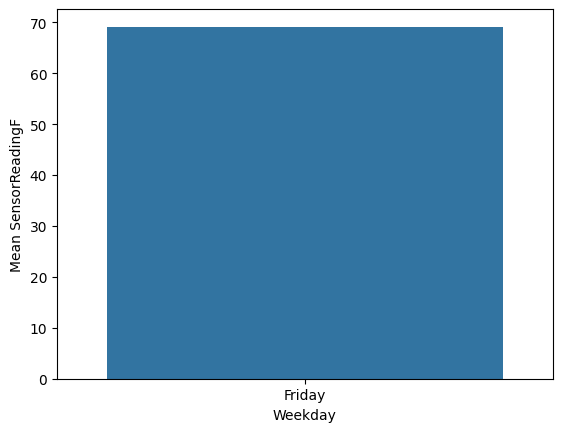

In [8]:
# Example: Average reading by Weekday. 

# join utcs to get weekday. 
# df converts results to a pandas DataFrame.

# use abs(dr.SensorReadingUTC - dr.QueryUTC) < 60 * 5 to remove old sensor readings.

import seaborn as sns

data = duckdb.sql("""
    SELECT day_of_week as Weekday, avg(SensorReadingF) as 'Mean SensorReadingF'
    FROM read_parquet('data/device_readings.parquet') AS dr
    INNER JOIN read_parquet('data/utcs.parquet') AS u ON 
        abs(dr.SensorReadingUTC - dr.QueryUTC) < 60 * 5 AND 
        dr.SensorReadingUTC = u.UTC
    GROUP BY day_of_week
""").df()

sns.barplot(x = 'Weekday', y = 'Mean SensorReadingF', data = data)

<Axes: xlabel='Weekday', ylabel='Mean SensorReadingF'>

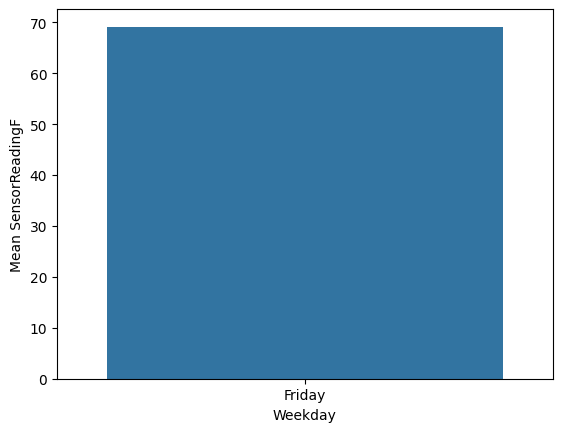

In [9]:
# Example: Average reading by Weekday - using the cubes.

# join utcs to get weekday. 
# df converts results to a pandas DataFrame.

# cubes already have old sensor readings removed. 

import seaborn as sns

data = duckdb.sql("""
    SELECT day_of_week as Weekday, sum(SensorReadingF_sum) / sum(row_count) as 'Mean SensorReadingF'
    FROM read_parquet('data/device_readings_daily.parquet') AS drd
    INNER JOIN (SELECT DISTINCT date, day_of_week FROM read_parquet('data/utcs.parquet')) AS u
        ON drd.date = u.date
    GROUP BY day_of_week
""").df()

# need DISTINCT on utcs to prevent duplication.

sns.barplot(x = 'Weekday', y = 'Mean SensorReadingF', data = data)

In [10]:
# Buildings: Number of Devices, First Reading.

# join utcs to get date. 
# join devices to get building info.
# df converts results to a pandas DataFrame.

duckdb.sql("""
    SELECT Building, min(date) as 'First Reading', count(DISTINCT dr.DeviceID_Coris) as 'Count of Devices'
    FROM read_parquet('data/device_readings.parquet') AS dr
    INNER JOIN read_parquet('data/utcs.parquet') AS u
        ON dr.SensorReadingUTC = u.UTC
    INNER JOIN read_parquet('data/devices.parquet') AS d
        ON d.DeviceID_Coris = dr.DeviceID_Coris
    GROUP BY Building
    ORDER BY min(date)
""").df()

,Building,First Reading,Count of Devices
0,Kline Geology Laboratory,2022-10-19,9
1,Collection Studies Center (West Campus),2022-10-19,20
2,Yale Peabody Museum,2022-10-19,22
3,Environmental Science Center,2022-10-19,10
4,,2022-10-19,4


In [11]:
# Readings that differ from the Query UTC.
duckdb.sql("""
    SELECT QueryUTC, SensorReadingUTC, (SensorReadingUTC - QueryUTC) / 60 as 'Difference (Minutes)'
    FROM read_parquet('data/sensor_readings.parquet') 
    WHERE abs(SensorReadingUTC - QueryUTC) > 60 * 1
    ORDER BY abs(SensorReadingUTC - QueryUTC) DESC
""").df()

,QueryUTC,SensorReadingUTC,Difference (Minutes)
0,1729277074,1700063665,-486890.150000
1,1729277074,1700063665,-486890.150000
2,1729277074,1718935710,-172356.066667
3,1729277074,1718935710,-172356.066667
4,1729277074,1729276600,-7.900000
...,...,...,...
95,1729277074,1729276985,-1.483333
96,1729277074,1729276996,-1.300000
97,1729277074,1729276996,-1.300000
98,1729277074,1729277010,-1.066667
